# **Imports**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import string
import re
import warnings

warnings.filterwarnings('ignore')

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

# **Load Dataset**

In [ ]:
data = pd.read_csv('/content/spam.csv', encoding='latin1')

# **Data Cleaning**

In [ ]:
# Remove useless columns
data = data.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])

In [ ]:
# Rename columns
data = data.rename(columns={
    'v1': 'Target',
    'v2': 'Text'
})

In [ ]:
# Remove duplicates
data = data.drop_duplicates(keep='first')

In [ ]:
# Check shape
print(data.shape)

(5169, 2)


In [ ]:
# Check missing values
print(data.isnull().sum())

Target    0
Text      0
dtype: int64


In [ ]:
# Target Encoding
data['Target'] = data['Target'].replace({
    'ham': 0,
    'spam': 1
})

# **EDA**

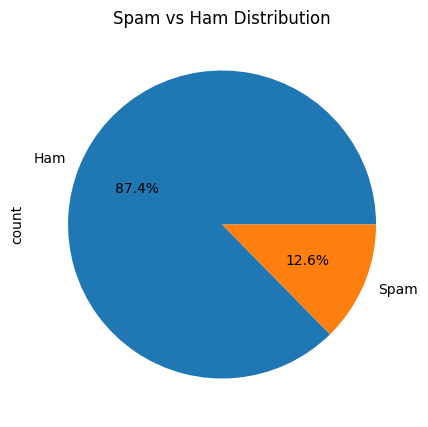

In [ ]:
# Target distribution
plt.figure(figsize=(5,5))

data['Target'].value_counts().plot.pie(
    autopct='%.1f%%',
    labels=['Ham', 'Spam']
)

plt.title('Spam vs Ham Distribution')
plt.show()

# **Feature Engineering**

In [ ]:
data['Num_Char'] = data['Text'].apply(len)

In [ ]:
data['Word_Num'] = data['Text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [ ]:
data['Sent_Num'] = data['Text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [ ]:
print(data.head())

   Target                                               Text  Num_Char  \
0       0  Go until jurong point, crazy.. Available only ...       111   
1       0                      Ok lar... Joking wif u oni...        29   
2       1  Free entry in 2 a wkly comp to win FA Cup fina...       155   
3       0  U dun say so early hor... U c already then say...        49   
4       0  Nah I don't think he goes to usf, he lives aro...        61   

   Word_Num  Sent_Num  
0        24         2  
1         8         2  
2        37         2  
3        13         1  
4        15         1  


# **Data Visualization**

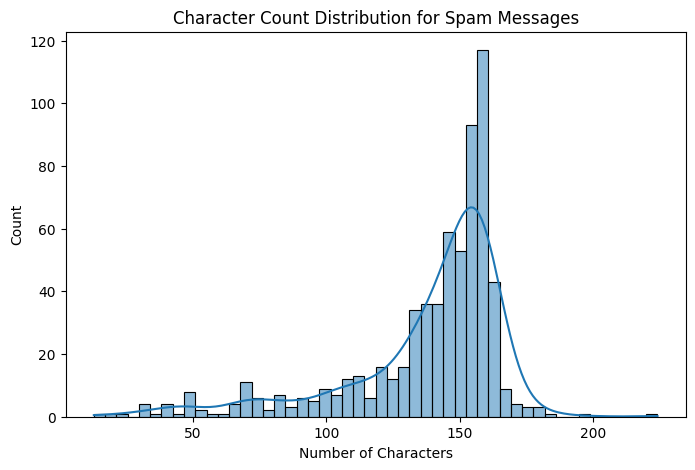

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    data[data['Target'] == 1]['Num_Char'],
    bins=50,
    kde=True
)
plt.title('Character Count Distribution for Spam Messages')
plt.xlabel('Number of Characters')
plt.show()

In [ ]:
df = data[['Target', 'Num_Char', 'Word_Num', 'Sent_Num']]

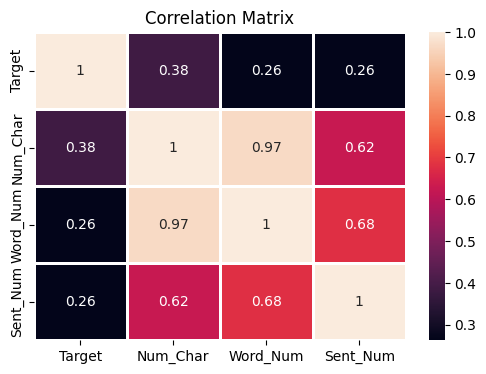

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(
    df.corr(),
    annot=True,
    linewidths=1
)

plt.title('Correlation Matrix')
plt.show()


# **Text Preprocessing**

In [ ]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = stopwords.words('english')
lemmatizer = WordNetLemmatizer()
punc = string.punctuation

In [ ]:
def preprocess_text(text):

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Tokenization
    tokens = nltk.word_tokenize(text)

    cleaned_tokens = []

    for word in tokens:

        if word not in punc and word not in stop_words:

            # Lemmatization
            word = lemmatizer.lemmatize(word, pos='v')

            cleaned_tokens.append(word)

    return " ".join(cleaned_tokens)

In [ ]:
data['Processed_Text'] = data['Text'].apply(preprocess_text)

In [ ]:
    print(data[['Text', 'Processed_Text']].head())

                                                Text  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                      Processed_Text  
0  go jurong point crazy .. available bugis n gre...  
1                      ok lar ... joke wif u oni ...  
2  free entry wkly comp win fa cup final tkts st ...  
3        u dun say early hor ... u c already say ...  
4            nah n't think go usf live around though  


# **Data Modeling**

In [ ]:
from sklearn.model_selection import train_test_split
X = data['Processed_Text']
y = data['Target']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
# models
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

In [ ]:
# metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)

MultinomialNB
Accuracy : 0.9748549323017408
Precision: 1.0
Recall   : 0.8206896551724138
F1 Score : 0.9015151515151515

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       889
           1       1.00      0.82      0.90       145

    accuracy                           0.97      1034
   macro avg       0.99      0.91      0.94      1034
weighted avg       0.98      0.97      0.97      1034



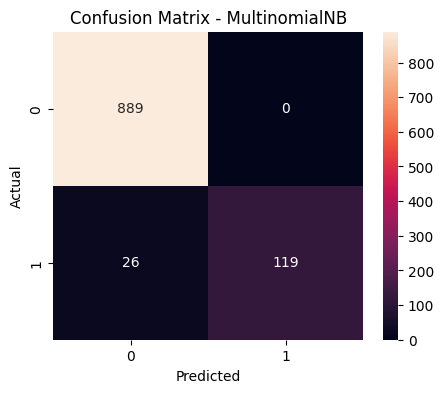

BernoulliNB
Accuracy : 0.9787234042553191
Precision: 0.984251968503937
Recall   : 0.8620689655172413
F1 Score : 0.9191176470588235

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       889
           1       0.98      0.86      0.92       145

    accuracy                           0.98      1034
   macro avg       0.98      0.93      0.95      1034
weighted avg       0.98      0.98      0.98      1034



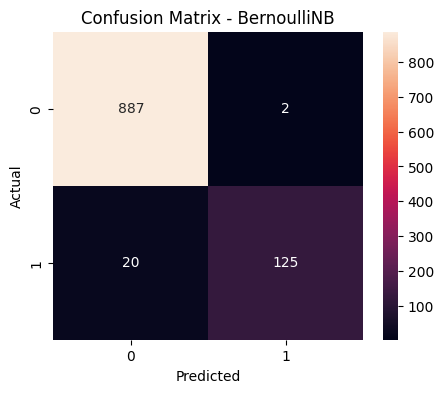

LogisticRegression
Accuracy : 0.9671179883945842
Precision: 0.944
Recall   : 0.8137931034482758
F1 Score : 0.8740740740740741

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       889
           1       0.94      0.81      0.87       145

    accuracy                           0.97      1034
   macro avg       0.96      0.90      0.93      1034
weighted avg       0.97      0.97      0.97      1034



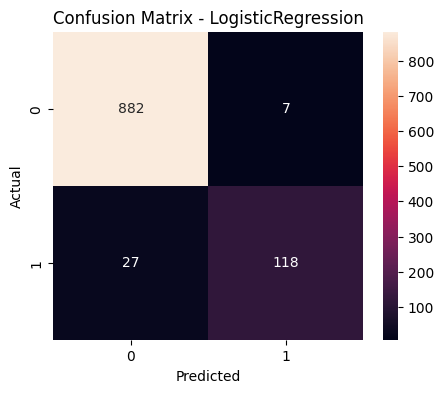

LinearSVC
Accuracy : 0.9854932301740812
Precision: 0.9710144927536232
Recall   : 0.9241379310344827
F1 Score : 0.9469964664310954

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       889
           1       0.97      0.92      0.95       145

    accuracy                           0.99      1034
   macro avg       0.98      0.96      0.97      1034
weighted avg       0.99      0.99      0.99      1034



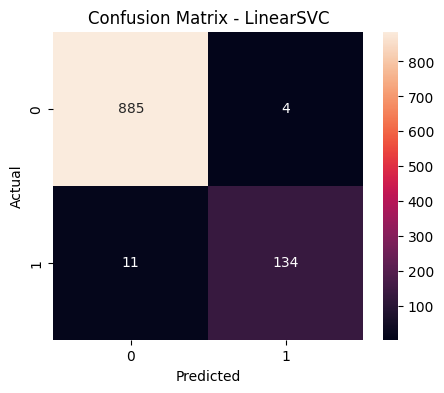

In [ ]:
models = {
    'MultinomialNB': MultinomialNB(),
    'BernoulliNB': BernoulliNB(),
    'LogisticRegression': LogisticRegression(),
    'LinearSVC': LinearSVC()
}

results = []

for name, model in models.items():

    model.fit(X_train_tfidf, y_train)
    pred = model.predict(X_test_tfidf)


    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

    print("="*50)
    print(name)
    print("="*50)
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    print("\nClassification Report:\n")
    print(classification_report(y_test, pred))


    # Confusion Matrix
    plt.figure(figsize=(5,4))

    sns.heatmap(
        confusion_matrix(y_test, pred),
        annot=True,
        fmt='d'
    )

    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.show()



In [ ]:
results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
)

print(results_df)

                Model  Accuracy  Precision    Recall  F1 Score
0       MultinomialNB  0.974855   1.000000  0.820690  0.901515
1         BernoulliNB  0.978723   0.984252  0.862069  0.919118
2  LogisticRegression  0.967118   0.944000  0.813793  0.874074
3           LinearSVC  0.985493   0.971014  0.924138  0.946996


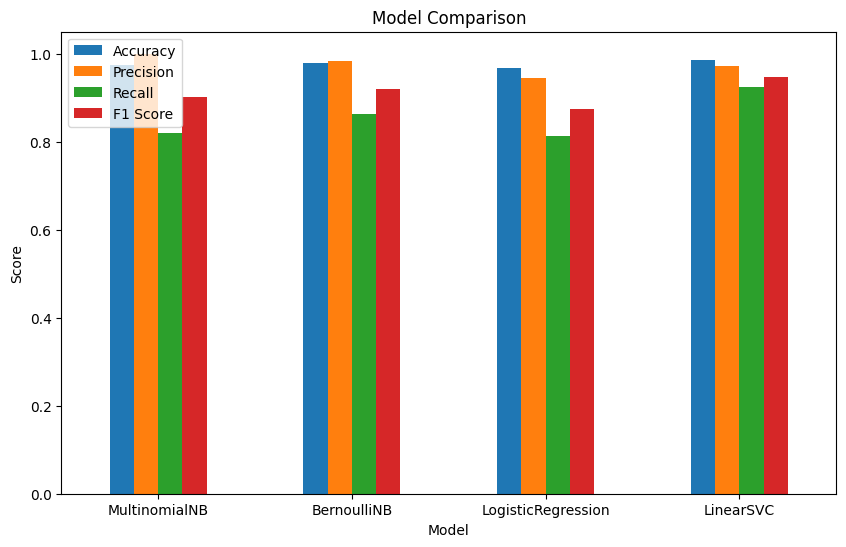

In [ ]:
# Compare Models
results_df.plot(
    x='Model',
    y=['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    kind='bar',
    figsize=(10,6)
)

plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.show()

In [ ]:
best_model = LinearSVC()

best_model.fit(X_train_tfidf, y_train)

LinearSVC()

# **Save Model**

In [ ]:
import pickle

pickle.dump(best_model, open('spam_model.pkl', 'wb'))
pickle.dump(tfidf, open('tfidf_vectorizer.pkl', 'wb'))

print("Model Saved Successfully!")

Model Saved Successfully!


# **Test on Custom Message**

In [ ]:
sample = "Congratulations! You won a free iPhone. Click now!"

sample = preprocess_text(sample)

sample_vector = tfidf.transform([sample])

prediction = best_model.predict(sample_vector)

if prediction[0] == 1:
    print("Spam Message")
else:
    print("Ham Message")

Ham Message
